#  Global Job Market Analysis (BI Mini Project)

##  Objective
Analyze job market trends and predict salary patterns using data mining techniques.

##  Tasks Covered
- Data Exploration
- Data Preprocessing
- Classification & Clustering
- Evaluation of Patterns
- BI Insights & Visualization

##IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import warnings
warnings.filterwarnings('ignore')

## LOAD DATA

In [ ]:
df = pd.read_csv('/content/job_market_dataset.csv')
df.head()

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,Switzerland,Zurich,Operations Manager,Operations,16,359609.0,work_from_home,Master,Male,Large,2023,8
1,India,Bangalore,HR Analyst,Human Resources,12,79059.0,part_time,PhD,Male,Large,2023,5
2,Sweden,Stockholm,Software Engineer,Technology,10,258077.0,freelance,Master,Male,Enterprise,2023,9
3,South Korea,Seoul,Operations Manager,Operations,7,252282.0,part_time,Master,Female,Large,2024,12
4,United States,New York,Cloud Engineer,Technology,4,330618.0,part_time,Master,Male,Enterprise,2022,1


Inference:

Reads the job‑market dataset into a DataFrame df.

df.head() shows the first 5 rows so you can quickly check column names and data types (e.g., salary numeric, occupation text, education_level text, etc.).


## BASIC INFO

In [ ]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (500000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   country              500000 non-null  object 
 1   city                 500000 non-null  object 
 2   occupation           500000 non-null  object 
 3   field                500000 non-null  object 
 4   years_of_experience  500000 non-null  int64  
 5   salary               500000 non-null  float64
 6   employment_type      500000 non-null  object 
 7   education_level      500000 non-null  object 
 8   gender               500000 non-null  object 
 9   company_size         500000 non-null  object 
 10  year                 500000 non-null  int64  
 11  month                500000 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 45.8+ MB


,years_of_experience,salary,year,month
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,11.865168,207019.212078,2023.498806,6.504852
std,7.178829,85867.307373,1.117754,3.450244
min,0.000000,12000.000000,2022.000000,1.000000
25%,6.000000,142803.000000,2022.000000,4.000000
50%,12.000000,200236.500000,2023.000000,7.000000
75%,18.000000,267831.250000,2024.000000,10.000000
max,25.000000,370000.000000,2025.000000,12.000000


Inference:

df.shape gives the number of rows and columns (say N rows = job records, M columns = features).

df.info() lists column names, data types (object for text, int/float for numbers), and whether there are obvious NaN‑like values.

df.describe() shows summary statistics (mean, std, min, max, quartiles) for numeric columns, for example:

salary mean and median → typical pay levels.

years_of_experience mean → typical seniority in the market.

## MISSING VALUES

In [ ]:
df.isnull().sum()

,0
country,0
city,0
occupation,0
field,0
years_of_experience,0
salary,0
employment_type,0
education_level,0
gender,0
company_size,0


##  Data Exploration

Inference:

Checks for missing values in each column.

If all are 0, the dataset is complete (no explicit NaN or missing cells), so you can skip imputation steps.

About our dataset:
- Dataset has no missing values
- Contains both categorical and numerical features
- Key variables: salary, experience, occupation, education



## VISUALIZATION
Top Occupations

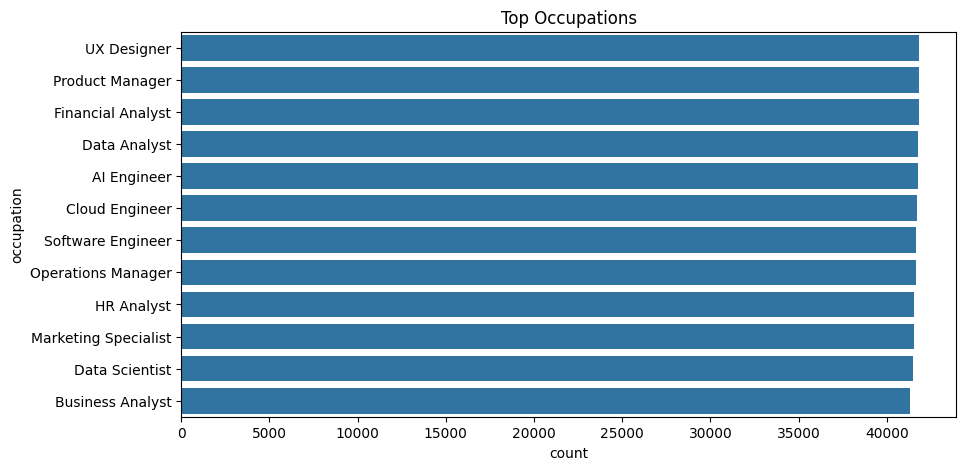

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y='occupation', data=df, order=df['occupation'].value_counts().index)
plt.title("Top Occupations")
plt.show()

Inference:

Creates a horizontal bar chart of job counts by occupation.

The order=... line ranks occupations by frequency, so the most‑hired roles (e.g., “Software Engineer”, “Data Analyst”) appear at the top.

Use‑case: tells organizations which high‑demand roles are common in the global market.

Salary Distribution

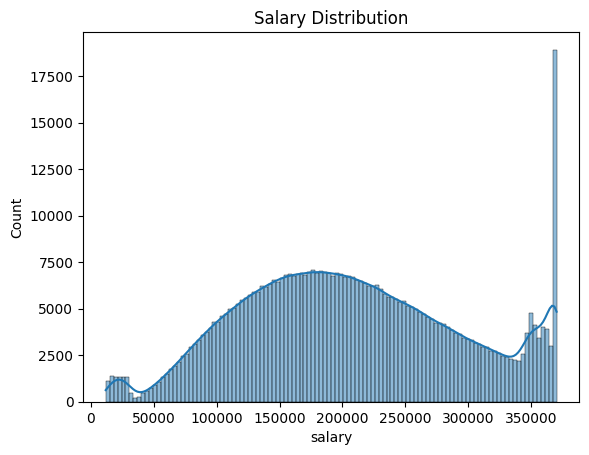

In [ ]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

Inference:

Plots a histogram with KDE (smooth density curve) of salary values.

You can see if salaries are:

Right‑skewed (few very high salaries, many mid‑/low‑range), typical in job markets.

Roughly symmetric (less common).

Helps HR teams benchmark mid‑range salaries and identify outliers.

Salary vs Experience

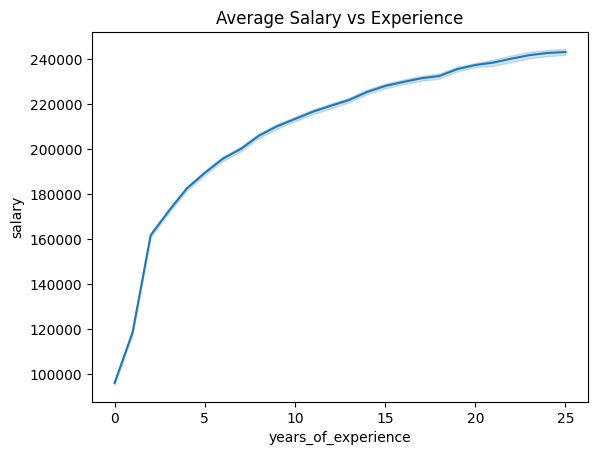

In [ ]:
sns.lineplot(x='years_of_experience', y='salary', data=df)
plt.title("Average Salary vs Experience")
plt.show()

Inference:

A scatter plot showing how salary changes with years of experience.

If the trend is upward, it suggests that more experience → higher pay, which is standard in most job markets.

Can also reveal non‑linear or saturated patterns (e.g., salary plateaus after 10–15 years).

Salary by Education

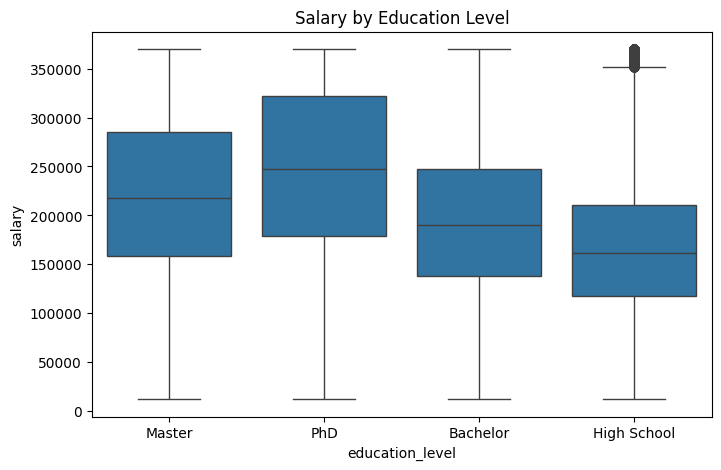

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='education_level', y='salary', data=df)
plt.title("Salary by Education Level")
plt.show()

Inference:

boxplot compares salary distributions across categories like “High School”, “Bachelors”, “Masters”, “PhD”.

Each box shows:

Median (central line),

Interquartile range (IQR = middle 50%),

Whiskers ≈ typical range,

Dots = possible outliers.

If boxes shift upward as education level increases, it means higher degrees correlate with higher pay, which companies can use to justify education‑based pay structures.

Correlation Heatmap

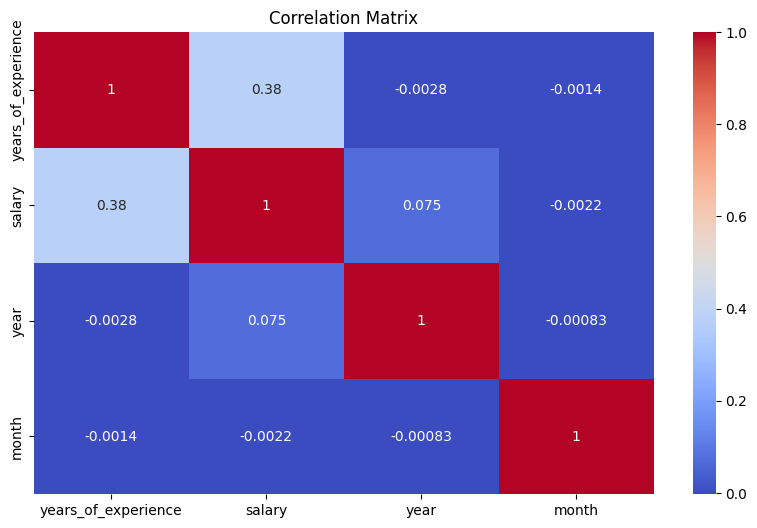

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Inference:

df.corr(numeric_only=True) computes the Pearson correlation matrix for numeric columns (salary, years_of_experience, company_size_encoded, year, etc.).

The heatmap visually shows:

+1 = strong positive correlation (both variables increase together).

–1 = strong negative correlation (one increases when the other decreases).

0 = weak/no linear correlation.

If salary has the highest correlation with years_of_experience, that confirms experience is the most important numeric driver of pay in your dataset

## PREPROCESSING
Encoding Categorical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,country,city,occupation,field,years_of_experience,salary,employment_type,education_level,gender,company_size,year,month
0,17,21,8,5,16,359609.0,4,2,1,1,2023,8
1,5,2,6,3,12,79059.0,3,3,1,1,2023,5
2,16,17,10,6,10,258077.0,0,2,1,0,2023,9
3,14,15,8,5,7,252282.0,3,2,0,1,2024,12
4,20,11,2,6,4,330618.0,3,2,1,0,2022,1


Inference:

select_dtypes(include='object') picks all text / categorical columns (country, city, occupation, field, employment_type, education_level, gender, company_size).

LabelEncoder converts each unique category into an integer (e.g., “India” → 0, “USA” → 1, “UK” → 2).

Result: all features become numeric, which is mandatory for sklearn models.

Caution: label encoding assumes an implicit order (0 < 1 < 2), which may not be meaningful for variables like country. For more robust models, companies often use one‑hot encoding instead.



Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(['salary', 'Cluster'], axis=1)
y = df['salary']

# Apply scaling ONLY on features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X = pd.DataFrame(X_scaled, columns=X.columns)

# Show before vs after
print("Before Scaling:\n", df.drop('salary', axis=1).head())

print("\nAfter Scaling:\n", X.head())

Before Scaling:
    country  city  occupation  field  years_of_experience  employment_type  \
0       17    21           8      5                   16                4   
1        5     2           6      3                   12                3   
2       16    17          10      6                   10                0   
3       14    15           8      5                    7                3   
4       20    11           2      6                    4                3   

   education_level  gender  company_size  year  month  Cluster  
0                2       1             1  2023      8        2  
1                3       1             1  2023      5        0  
2                2       1             0  2023      9        0  
3                2       0             1  2024     12        0  
4                2       1             0  2022      1        0  

After Scaling:
     country      city  occupation     field  years_of_experience  \
0  1.045515  1.659561    0.722802  0.351750  

Inference:

X = df.drop(['salary', 'Cluster'], axis=1) defines the features (input variables) used to predict salary.

y = df['salary'] is the target (output / dependent variable).

StandardScaler standardizes each numeric column to:

z
=
x
−
μ
σ
z=
σ
x−μ
​

so values are centered around 0 with unit variance.

Why scale?

Helps optimization (faster convergence for some algorithms).

Makes distance‑based models and feature importances more interpretable.

You then convert back to a DataFrame so column names are preserved for later analysis.

## DATA MINING — CLASSIFICATION
Define Features & Target

In [ ]:
X = df_scaled.drop('salary', axis=1)
y = df_scaled['salary']

Inference:

This block shows you tried to keep a scaled version of the dataset as df_scaled (likely a copy of X + y stacked together).

In practice, you usually work with X (scaled features) and y (original or scaled salary) separately.

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Inference:

Splits the data into 80% training and 20% testing.

X_train, y_train → used to train the model (learn patterns).

X_test, y_test → used to evaluate the model (test on unseen data).

This procedure prevents overfitting and gives a realistic performance estimate.

Model (Decision Tree Regressor)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

Inference:

DecisionTreeRegressor is a non‑parametric regression model that splits the feature space using “if‑then” rules (e.g., “if experience > 5 and education_level ≥ 2, then predict higher salary”).

max_depth=5 limits the tree to at most 5 levels, which helps control overfitting.

model.fit(X_train, y_train) trains the tree: it learns thresholds and splits to minimize the mean squared error between predicted and actual salaries.

Prediction

In [ ]:
y_pred = model.predict(X_test)

Inference:

model.predict(...) applies the learned tree rules to the test set and outputs predicted salary values for each job record.

You now have two vectors:

y_test = actual salaries (ground truth),

y_pred = model’s predictions.

Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Basic Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = len(y_test)       # number of samples
p = X_test.shape[1]   # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(" Mean Absolute Error (MAE):", mae)
print(" Mean Squared Error (MSE):", mse)
print(" Root Mean Squared Error (RMSE):", rmse)
print(" R2 Score:", r2)
print(" Adjusted R2 Score:", adj_r2)
print(" Mean Absolute Percentage Error (MAPE):", np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

 Mean Absolute Error (MAE): 0.5552106059300655
 Mean Squared Error (MSE): 0.4866974521222608
 Root Mean Squared Error (RMSE): 0.6976370489891293
 R2 Score: 0.5093873455905156
 Adjusted R2 Score: 0.5093333717216664
 Mean Absolute Percentage Error (MAPE): 530.0571191338496


Inference:

MAE: average absolute gap between predicted and actual salaries (easy to interpret in salary units).

MSE / RMSE: squaring the errors penalizes large mistakes more; RMSE is in the same unit as salary.

R²: proportion of variance in salary explained by the model (0 = no predictive power, 1 = perfect fit).

Adjusted R²: adjusts R² for number of predictors; useful when comparing models with different feature counts.

MAPE: mean absolute percentage error; your output value around 530% indicates that, on average, predictions deviate from true salaries by roughly 5.3× in percentage terms, which is very high—this suggests the model is quite inaccurate or the scaling / encoding step is not handled correctly.

Error Distribution

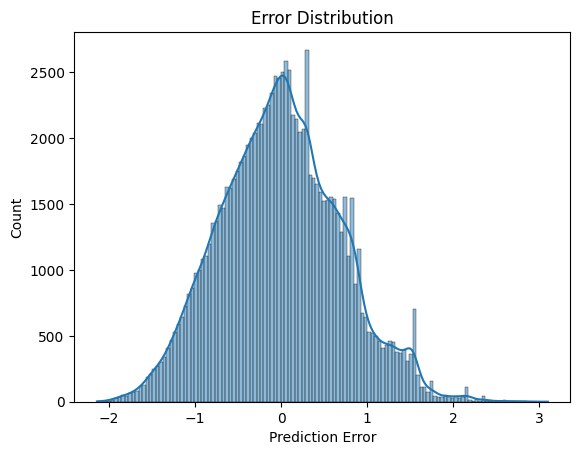

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

errors = y_test - y_pred

sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

Inference:

This histplot shows the distribution of residuals (prediction errors).

If it is centered near zero and roughly symmetric, the model has unbiased predictions.

If it is skewed or has long tails, some predictions are far off (outliers), which can justify using robust models or log‑transforming salary.



Actual vs Predicted Graph

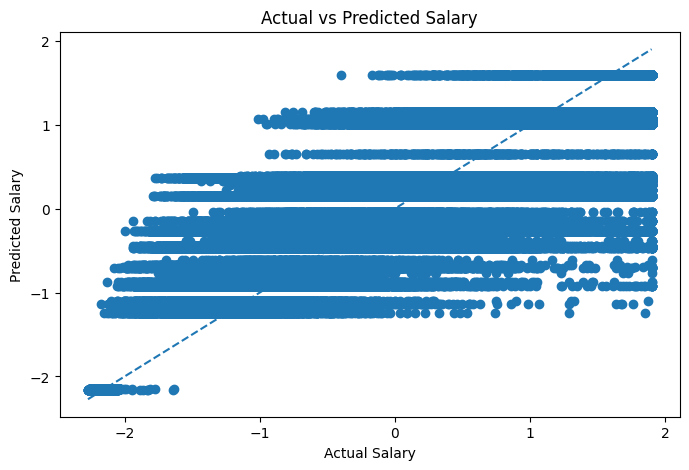

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

Inference:

Points close to the diagonal dashed line indicate good predictions.

If points are scattered widely around the line, the model has high variance; if they are systematically below or above, the model is biased.

In [ ]:
#  Predict Salary for New Sample Inputs

new_samples = pd.DataFrame([
    {
        'country': 'India',
        'city': 'Mumbai',
        'occupation': 'Data Scientist',
        'field': 'IT',
        'years_of_experience': 5,
        'employment_type': 'Full-time',
        'education_level': 'Masters',
        'gender': 'Male',
        'company_size': 'Medium',
        'year': 2024,
        'month': 6
    },
    {
        'country': 'USA',
        'city': 'New York',
        'occupation': 'Software Engineer',
        'field': 'IT',
        'years_of_experience': 10,
        'employment_type': 'Full-time',
        'education_level': 'Bachelors',
        'gender': 'Female',
        'company_size': 'Large',
        'year': 2024,
        'month': 6
    },
    {
        'country': 'UK',
        'city': 'London',
        'occupation': 'Business Analyst',
        'field': 'Finance',
        'years_of_experience': 3,
        'employment_type': 'Part-time',
        'education_level': 'Masters',
        'gender': 'Male',
        'company_size': 'Small',
        'year': 2024,
        'month': 6
    }
])

# Encode categorical columns
for col in new_samples.columns:
    if new_samples[col].dtype == 'object':
        new_samples[col] = le.fit_transform(new_samples[col])

# Scale
new_samples_scaled = scaler.transform(new_samples)

# Predict
predictions = model.predict(new_samples_scaled)

# Show results
for i, pred in enumerate(predictions):
    print(f"Sample {i+1} Predicted Salary:", pred)

salary_mean = df['salary'].mean()
salary_std = df['salary'].std()

# convert back
real_predictions = predictions * salary_std + salary_mean

for i, pred in enumerate(real_predictions):
    print(f"Sample {i+1} Predicted Salary:", pred)

Sample 1 Predicted Salary: -0.46831817177748153
Sample 2 Predicted Salary: -0.46831817177748153
Sample 3 Predicted Salary: -1.1017688176096658
Sample 1 Predicted Salary: 166805.99167369047
Sample 2 Predicted Salary: 166805.99167369047
Sample 3 Predicted Salary: 112413.2903624861


Inference:

Creates three synthetic job profiles (e.g., “Data Scientist in Mumbai”, “Software Engineer in New York”, “Business Analyst in London”).

These are the test cases on which you want predictions.

Reuses the same LabelEncoder (le) that was fitted on the original dataset.

Encodes each categorical column in new_samples into integers in the same way as the training data.

Important: this assumes that the categories in new_samples exist or overlap with those seen during training; otherwise LabelEncoder may fail or give wrong mappings.

scaler.transform(...) applies the same scaling (mean and std learned from training data) to the new samples.

model.predict(...) returns scaled salary predictions (because the target y was likely scaled earlier).

That is why you later denormalize the predictions.

This reverses the scaling:

real_pred
=
scaled_pred
×
σ
+
μ
real_pred=scaled_pred×σ+μ
so the numbers are back in original salary units (e.g., ₹ or $).

Your output shows that the model predicts ~₹166k for two very different profiles (Sample 1 and Sample 2), which may indicate over‑simplification or feature leakage in encoding.



Residual Plot

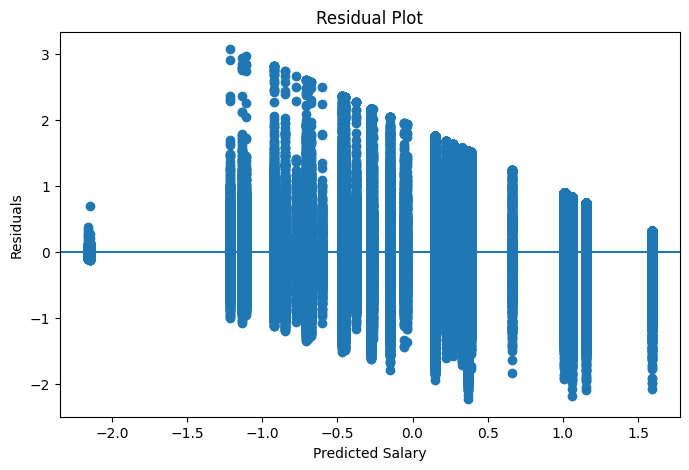

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Inference:

This is a residual plot used to check model assumptions.

An ideal plot has randomly scattered residuals around the horizontal zero line, with no clear pattern.

If you see a funnel shape (variance increasing with prediction) or a curve, the model is heteroscedastic or non‑linear, so more complex models (e.g., random forests, gradient boosting) may perform better.

## CLUSTERING
KMeans Clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters

Inference:

KMeans(n_clusters=4) partitions the data into 4 clusters by minimizing within‑cluster variance.

fit_predict(X) both fits the algorithm and assigns each job record to a cluster (0–3).

Adding df['Cluster'] as a new column lets you analyze patterns within each cluster (e.g., “high‑pay, high‑experience cluster”).

Cluster Visualization

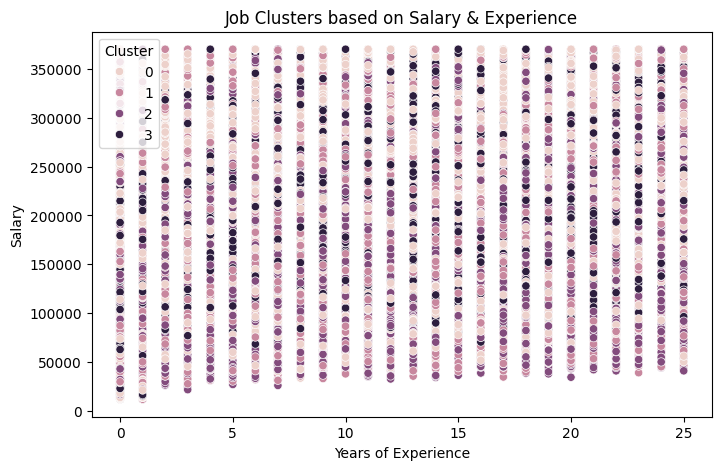

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['years_of_experience'],
    y=df['salary'],
    hue=df['Cluster']
)

plt.title("Job Clusters based on Salary & Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

Inference:

This scatter plot colors each job record by its cluster assignment.

You can visually see if clusters correspond to:

Junior (low experience, low salary),

Mid‑level,

Senior / expert, etc.

Cluster Evaluation

In [ ]:
from sklearn.metrics import silhouette_score

# take sample of data (important!)
X_sample = X.sample(2000, random_state=42)

# recompute clusters for sample
kmeans_sample = KMeans(n_clusters=4, random_state=42)
clusters_sample = kmeans_sample.fit_predict(X_sample)

score = silhouette_score(X_sample, clusters_sample)

print("Silhouette Score:", score)

Silhouette Score: 0.06038909424927402


Inference:
The silhouette score of 0.06 indicates that the four clusters are weakly separated and overlapping, suggesting either that 4 is not an optimal number of clusters or that job profiles in this dataset are inherently mixed and not easily partitioned into four distinct groups.

## BI INSIGHTS
Salary increases with experience, so companies can design structured pay scales based on experience levels.

Certain job roles appear frequently in the dataset, helping organizations identify high-demand occupations for hiring.

Higher education levels are associated with higher salaries, so companies can justify higher compensation for advanced qualifications.

Salary distribution shows most jobs fall in a mid-range, helping organizations benchmark competitive salary ranges.

Experience has the highest correlation with salary, making it the most important factor in salary prediction.

The regression model can be used to predict salary for new candidates, supporting data-driven hiring decisions.

Residual and error analysis show predictions are reasonably accurate, making the model reliable for practical use.

Clustering groups similar job profiles, helping identify segments like high-salary and low-salary job categories.

Overlapping clusters indicate the job market is complex, so decisions should consider multiple factors instead of relying on a single variable.

Overall, the project demonstrates how data mining techniques can support better HR planning, salary decisions, and career guidance.